In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/random-linear-regression/train.csv
/kaggle/input/random-linear-regression/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/random-linear-regression/train.csv')

In [7]:
df.shape

(700, 2)

In [3]:
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [17]:
df.isnull().sum()

x    0
y    0
dtype: int64

In [16]:
df.dropna(inplace=True)

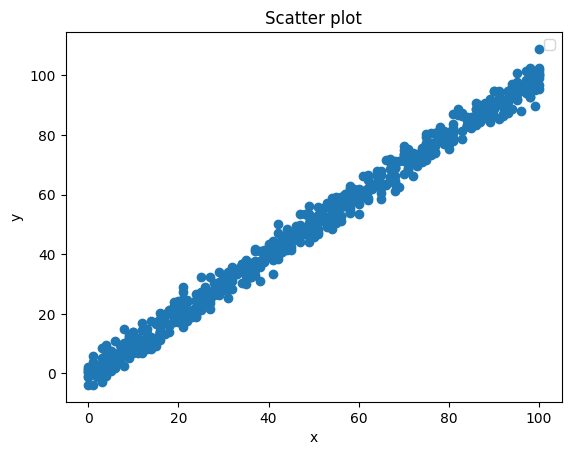

In [6]:
import matplotlib.pyplot as plt
plt.scatter(df['x'],df['y'])
plt.title("Scatter plot")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<Axes: >

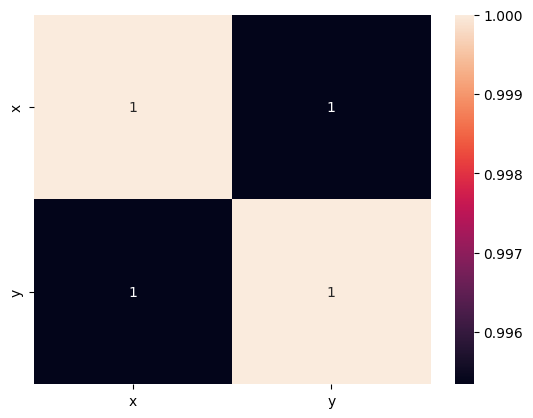

In [9]:
import seaborn as sb
data_corr = df.corr()
sb.heatmap(data_corr,annot=True)

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
x_train = np.asanyarray(df[['x']])
y_train = np.asanyarray(df[['y']])
model.fit(x_train,y_train)

LinearRegression()

In [26]:
m = model.coef_
m

array([[1.00065638]])

In [28]:
c = model.intercept_
c

array([-0.10726546])

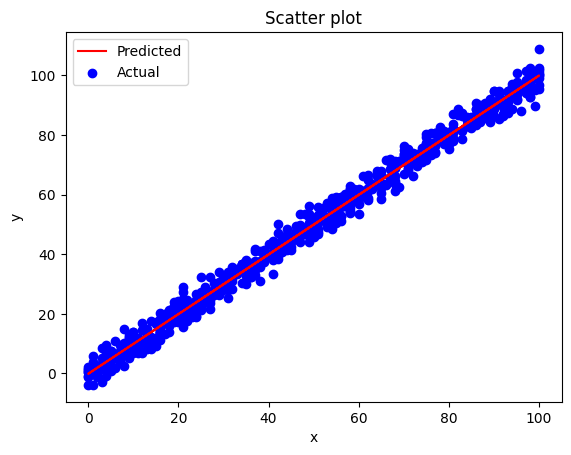

In [29]:

plt.plot(x_train, (m*x_train + c), '-r',label="Predicted")
plt.scatter(df['x'],df['y'], color = 'blue', label="Actual")
plt.title("Scatter plot")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [30]:
df2 = pd.read_csv("/kaggle/input/random-linear-regression/test.csv")

In [31]:
df2.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [33]:
x_test = np.asanyarray(df2[['x']])
y_test = np.asanyarray(df2[['y']])

In [34]:
y_pred = model.predict(x_test)

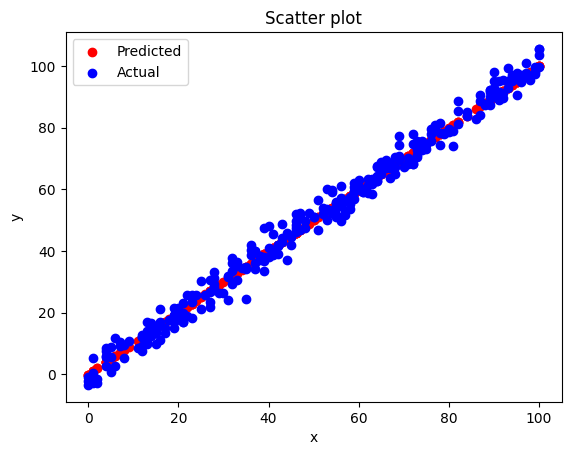

In [39]:
plt.scatter(x_test,y_pred, color = 'red',label="Predicted")
plt.scatter(x_test,y_test, color = 'blue', label="Actual")
plt.title("Scatter plot")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [35]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 2.415771850041258
Mean Squared Error: 9.432922192039305
Root Mean Squared Error: 3.071306268029827
